# Analysis: PCA trajectories, dPCA, spatial separation

Load stage-2 checkpoint, collect trials, analyse hidden-state geometry.

In [17]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src import BioLeakyRNN, CuedTargetWithDistractorsV3
from src.analysis import (
    collect_trials, filter_trials, select_trials,
    fit_pca_on_trials, get_aligned_pca_segments,
    compute_median_and_band, compute_mean_and_sem,
    dpca_marginals, collect_aligned_hidden_by_label, make_condition_mean_tensor,
    plot_spatial_separation_pca, print_centroid_distances, compare_spatial_separation,
)
from src.plotting import (
    plot_pca_trajectories, plot_pca_trajectories_by_outcome,
    plot_pc_timecourses, plot_two_group_pc_timecourses,
    plot_two_group_median_trajectories,
    plot_trialtype_panel, plot_dpca_components, plot_dpca_plane,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load model

In [18]:
def make_model():
    return BioLeakyRNN(
        input_size=7, hidden_size=128, output_size=2,
        dt=20.0, tau=100.0, activation='softplus', sigma_rec=0.05,
        use_ei=True, exc_ratio=0.7, use_dale=True, mask_seed=42,
    )

def make_env_stage2():
    return CuedTargetWithDistractorsV3(dt=20, cue_strength=1.0,
                                       p_distractor_trial=0.6, distractor_strength=1.0)

model = make_model().to(device)
model.load_state_dict(torch.load('../checkpoints/stage2.pt', weights_only=True)['state_dict'])
model.eval()
print('Loaded stage2 checkpoint.')

Loaded stage2 checkpoint.


C:\Users\savoj\projects\leaky-rnn-dale\.venv\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


## Collect trials

In [19]:
trials = collect_trials(model, make_env_stage2, n_trials=2000, device=device)
print(f'Collected {len(trials)} trials')
print(Counter(tr['train_outcome'] for tr in trials))

Collected 2000 trials
Counter({'correct': 1693, 'miss': 203, 'false_alarm': 104})


## PCA on hidden states

In [20]:
pca, trial_proj, explained = fit_pca_on_trials(trials, n_components=3)
print('Explained variance:', explained)

Explained variance: [0.54687779 0.14710396 0.10829587]


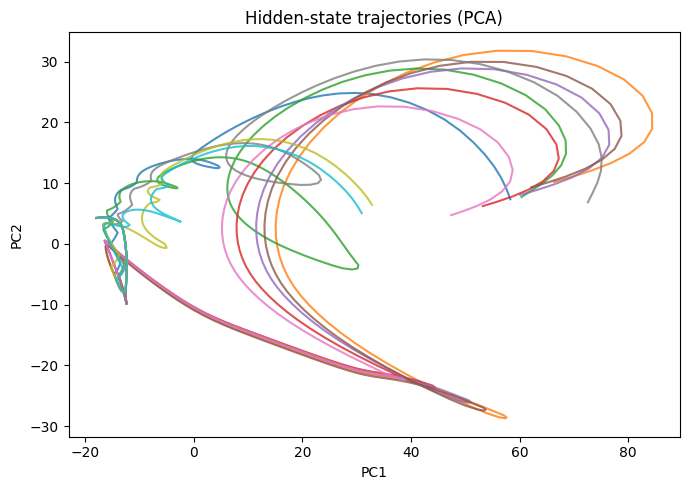

In [21]:
plot_pca_trajectories(trials, trial_proj, max_trials=10)

In [ ]:
plot_pca_trajectories_by_outcome(trials, trial_proj,
                                  outcomes=("correct", "false_alarm", "miss"),
                                  max_per_group=8)

## Event-aligned time courses

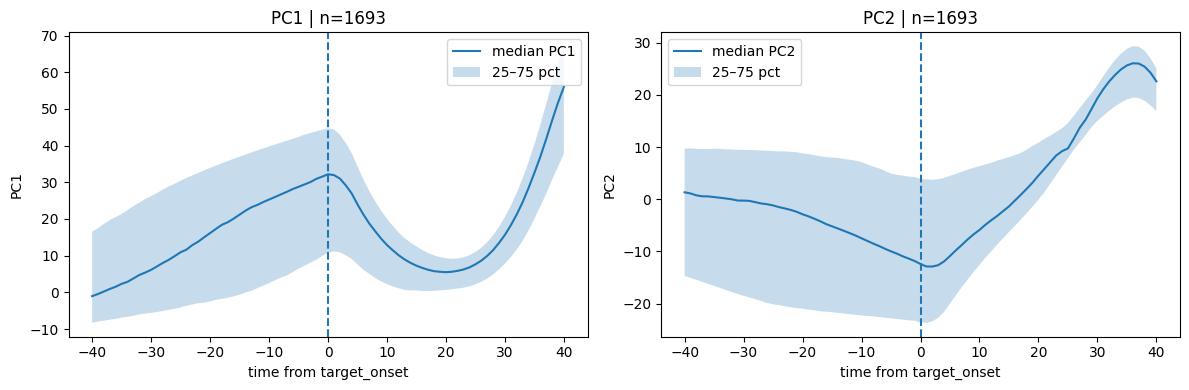

In [22]:
plot_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    stat_mode='median', train_outcome='correct',
)

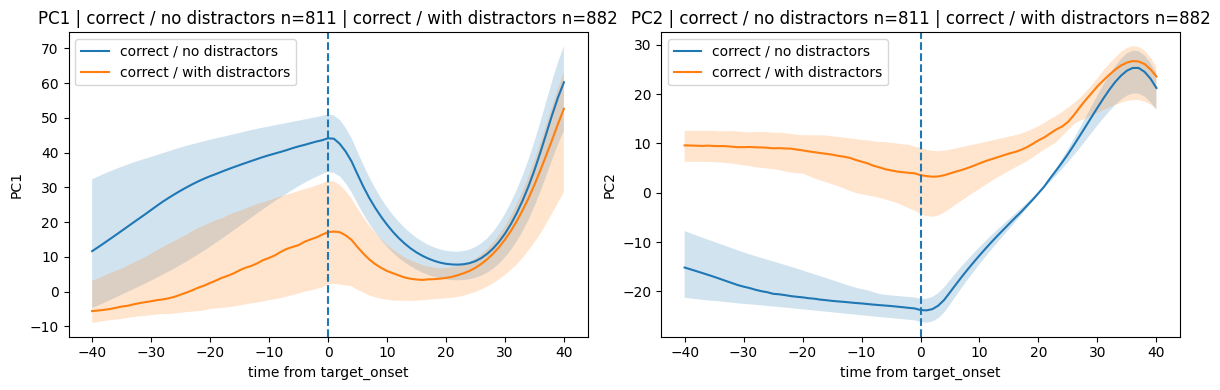

In [23]:
plot_two_group_pc_timecourses(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'correct', 'has_distractors': False},
    group2_kwargs={'train_outcome': 'correct', 'has_distractors': True},
    group1_label='correct / no distractors',
    group2_label='correct / with distractors',
)

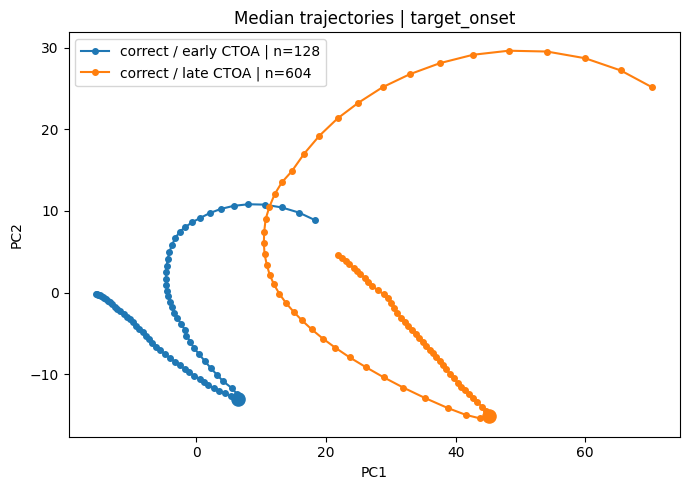

In [24]:
plot_two_group_median_trajectories(
    trials, trial_proj,
    align_key='target_onset', window_before=40, window_after=40,
    group1_kwargs={'train_outcome': 'correct', 'ctoa_bin_max': 2},
    group2_kwargs={'train_outcome': 'correct', 'ctoa_bin_min': 7},
    group1_label='correct / early CTOA',
    group2_label='correct / late CTOA',
)

## Panel: outcomes × CTOA × spatial location

In [ ]:
plot_trialtype_panel(
    trials, trial_proj,
    group_specs=[
        {'label': 'correct',     'train_outcome': 'correct'},
        {'label': 'miss',        'train_outcome': 'miss'},
        {'label': 'false_alarm', 'train_outcome': 'false_alarm'},
    ],
    align_key='target_onset', window_before=40, window_after=40,
    suptitle='All outcomes | target-locked',
)

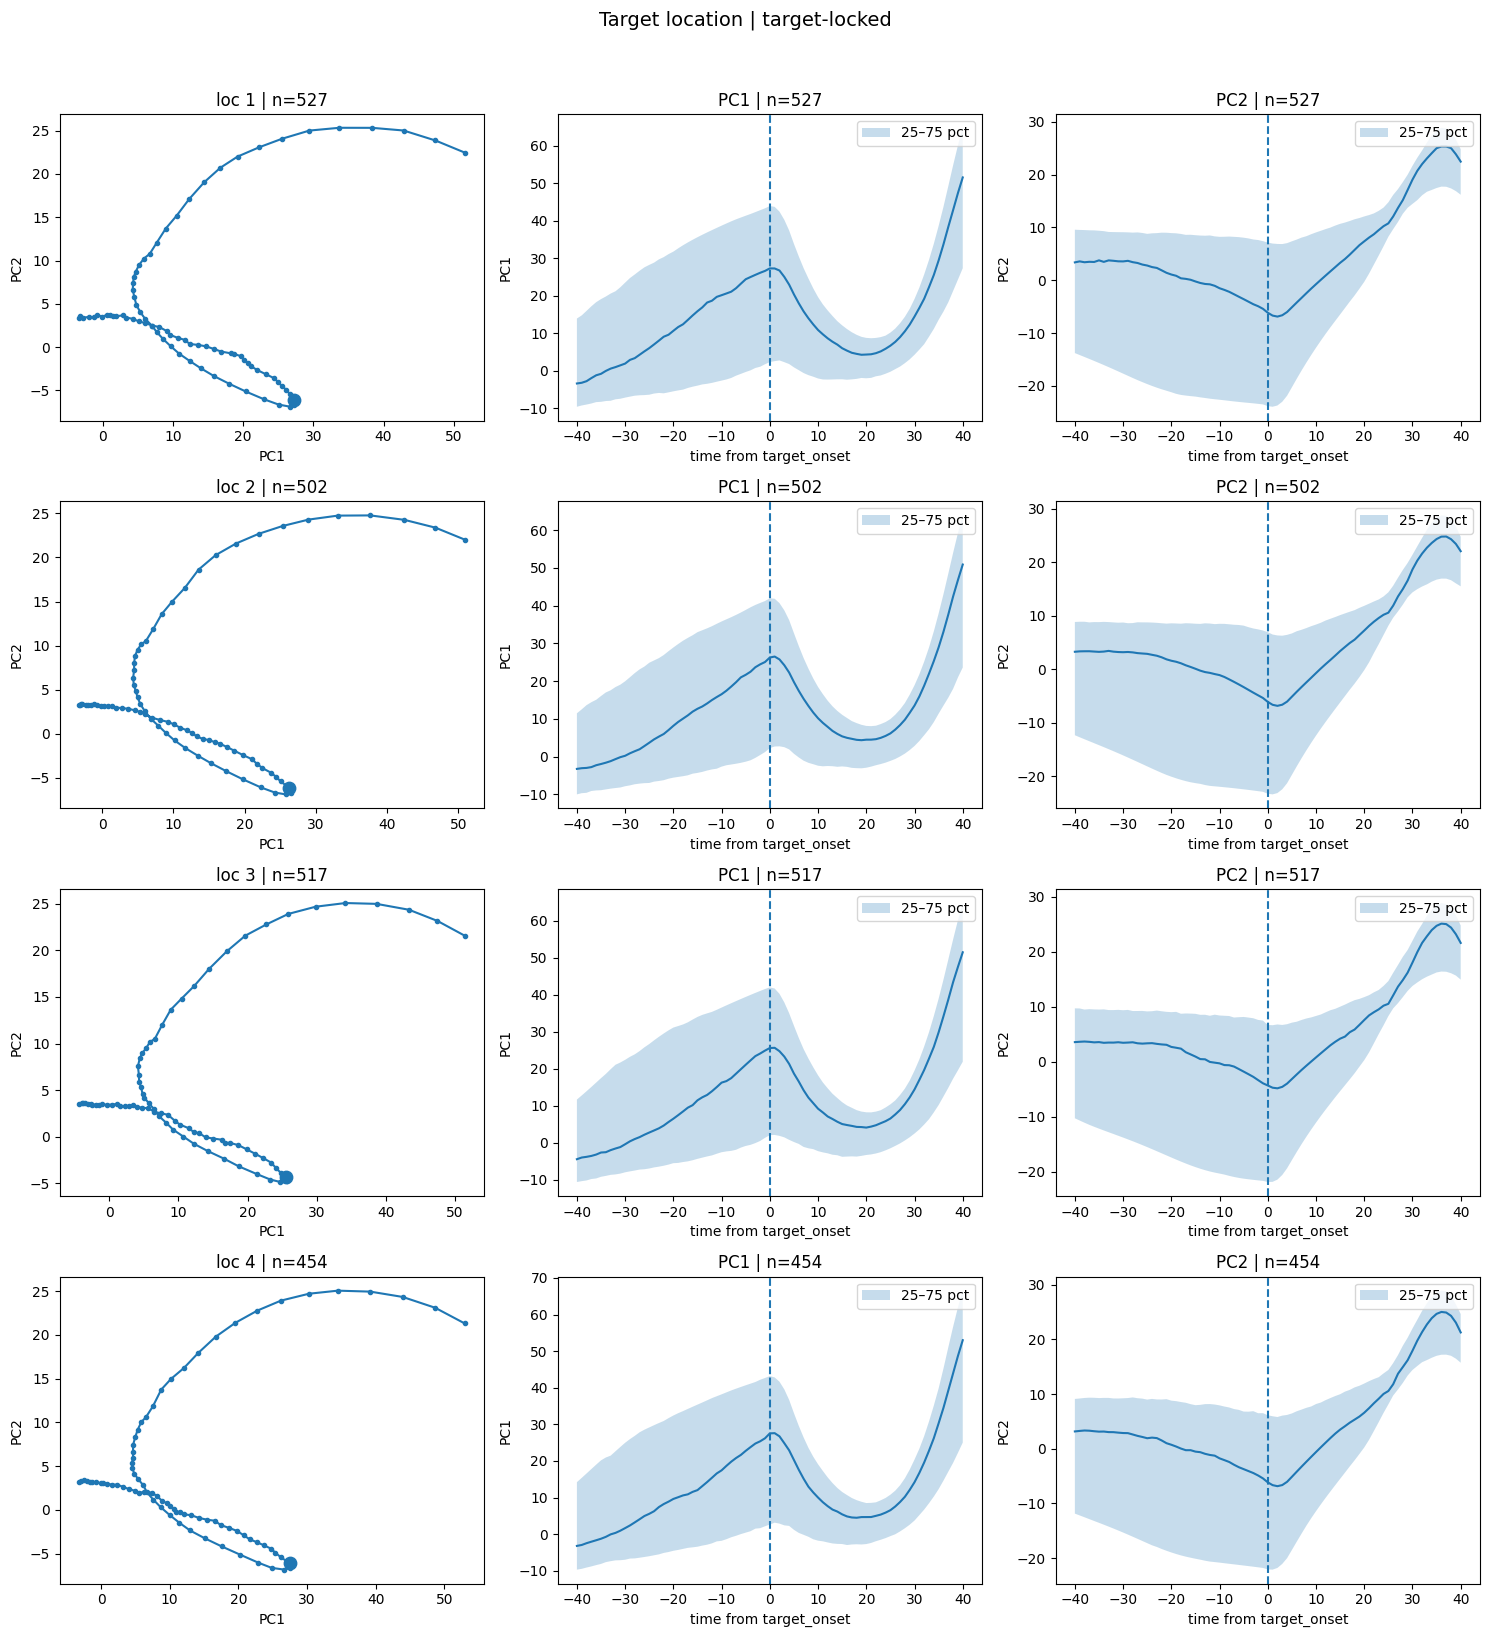

In [26]:
plot_trialtype_panel(
    trials, trial_proj,
    group_specs=[{'label': f'loc {i}', 'target_loc': i} for i in range(1, 5)],
    align_key='target_onset', window_before=40, window_after=40,
    suptitle='Target location | target-locked',
)

## dPCA: CTOA condition

In [27]:
by_ctoa, rel_time = collect_aligned_hidden_by_label(
    trials,
    label_fn=lambda tr: tr.get('ctoa_bin'),
    align_key='target_onset', window_before=40, window_after=40,
)
X_ctoa, ctoa_labels, ctoa_counts = make_condition_mean_tensor(by_ctoa, min_trials=5)
print('CTOA bins:', ctoa_labels, '  counts:', ctoa_counts)

res_ctoa = dpca_marginals(X_ctoa, n_components=3)
res_ctoa['rel_time'] = rel_time
res_ctoa['labels']   = ctoa_labels

CTOA bins: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]   counts: [27, 72, 141, 200, 290, 292, 299, 300, 245, 134]


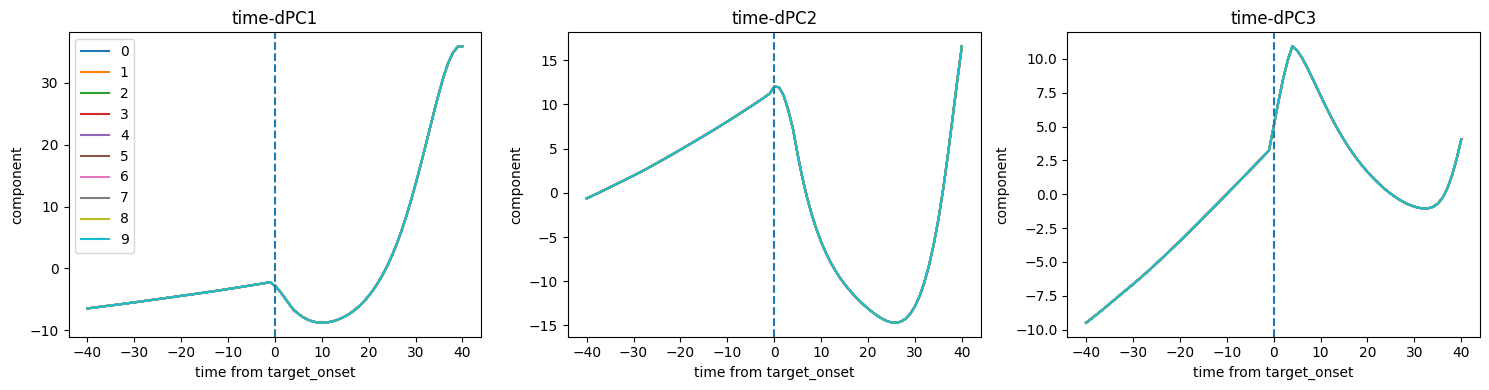

Explained variance (time): [0.54773426 0.30540755 0.10707587]


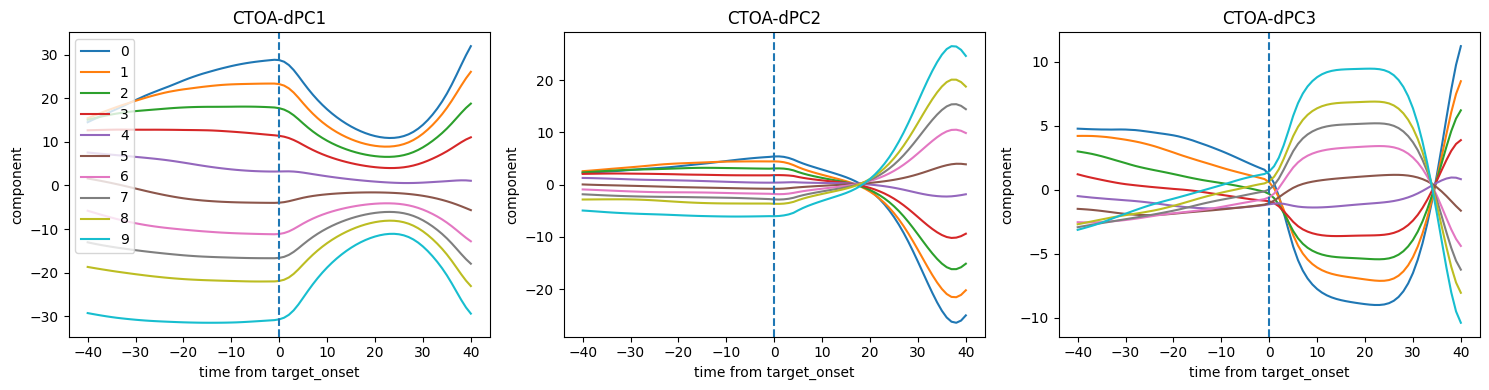

Explained variance (CTOA): [0.7667396  0.12756653 0.04358656]


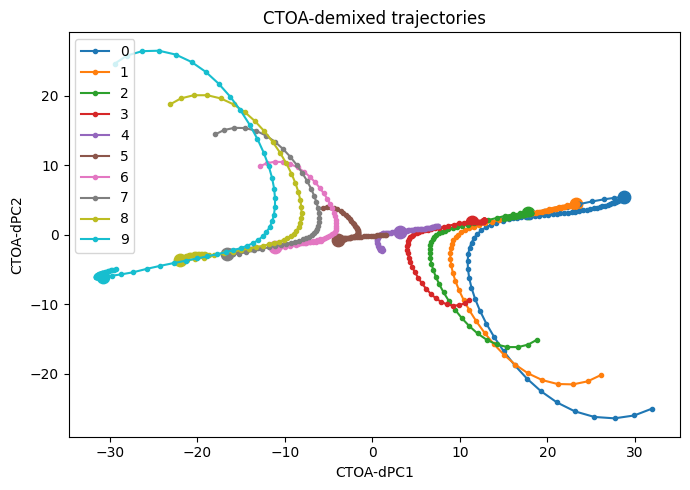

In [28]:
plot_dpca_components(res_ctoa, component_key='Z_time', explained_key='explained_time',
                     title_prefix='time', n_plot=3)
plot_dpca_components(res_ctoa, component_key='Z_cond', explained_key='explained_cond',
                     title_prefix='CTOA', n_plot=3)
plot_dpca_plane(res_ctoa, xlabel='CTOA-dPC1', ylabel='CTOA-dPC2',
                title='CTOA-demixed trajectories')

## Spatial separation analysis

Does the network represent target location in its hidden state?

In [29]:
# Collect more trials for spatial analysis (need enough per location)
trials_spatial = collect_trials(model, make_env_stage2, n_trials=800, device=device)
print(Counter(tr['train_outcome'] for tr in trials_spatial))

Counter({'correct': 654, 'miss': 105, 'false_alarm': 41})


correct: 654


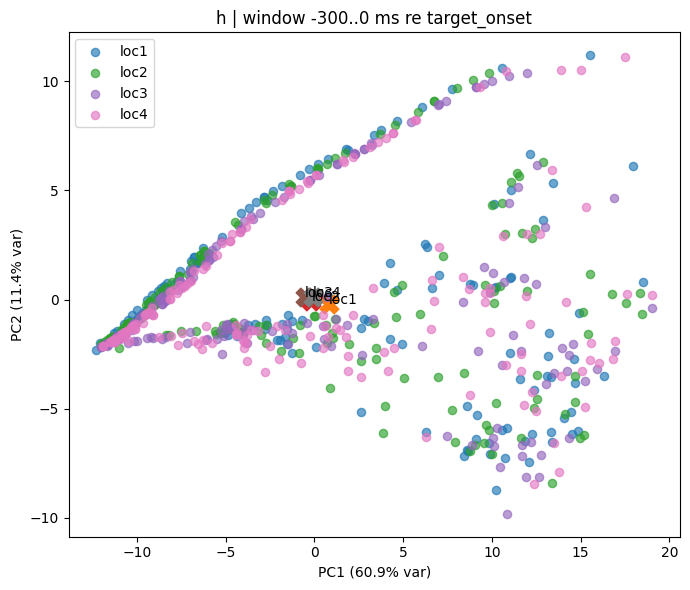

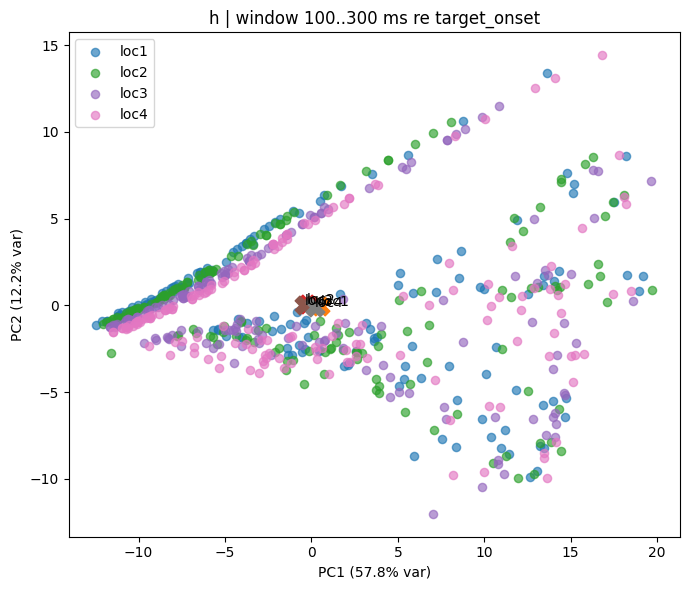

Pre-target
[[0.    1.007 1.419 0.987]
 [1.007 0.    0.427 0.21 ]
 [1.419 0.427 0.    0.453]
 [0.987 0.21  0.453 0.   ]]
Post-target
[[0.    0.813 0.934 0.299]
 [0.813 0.    0.15  0.537]
 [0.934 0.15  0.    0.645]
 [0.299 0.537 0.645 0.   ]]


array([[0.        , 0.81257355, 0.93357134, 0.29880047],
       [0.81257355, 0.        , 0.14957127, 0.53671664],
       [0.93357134, 0.14957127, 0.        , 0.64484543],
       [0.29880047, 0.53671664, 0.64484543, 0.        ]])

In [30]:
# All correct trials: pre- vs post-target
trials_correct = filter_trials(trials_spatial, outcome='correct')
print('correct:', len(trials_correct))

res_pre  = plot_spatial_separation_pca(trials_correct, align_key='target_onset', window_ms=(-300, 0))
res_post = plot_spatial_separation_pca(trials_correct, align_key='target_onset', window_ms=(100, 300))

print_centroid_distances(res_pre,  name='Pre-target')
print_centroid_distances(res_post, name='Post-target')

hit (distractor): 338,  FA (distractor): 41
hit: n=338,  false_alarm: n=41

--- hit pre-target ---


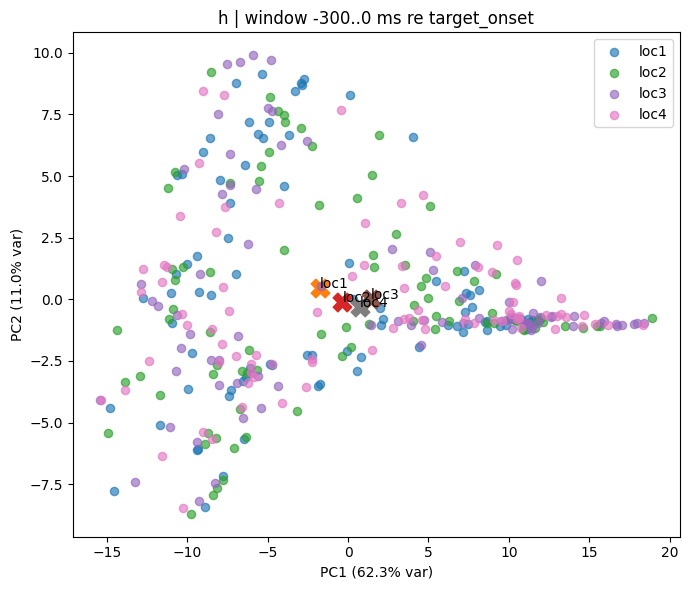

hit pre
[[0.    1.507 3.189 2.611]
 [1.507 0.    1.762 1.115]
 [3.189 1.762 0.    0.744]
 [2.611 1.115 0.744 0.   ]]

--- hit post-target ---


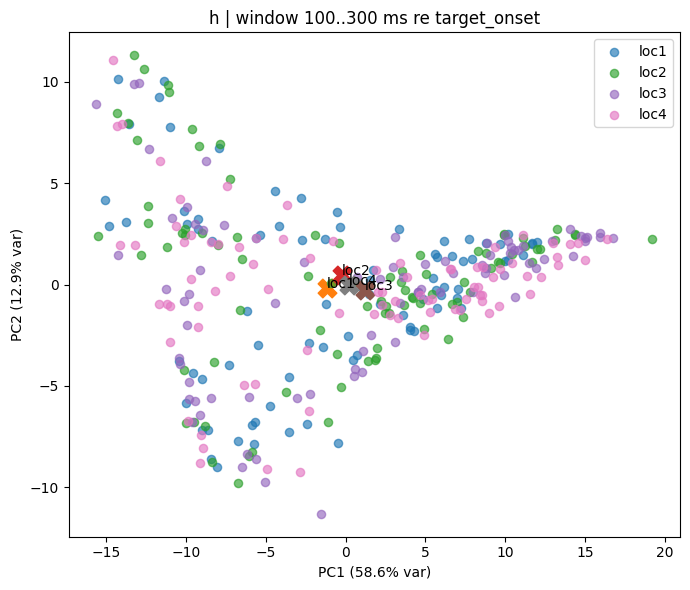

hit post
[[0.    1.131 2.372 1.374]
 [1.131 0.    1.638 0.682]
 [2.372 1.638 0.    1.034]
 [1.374 0.682 1.034 0.   ]]

--- false_alarm pre-target ---


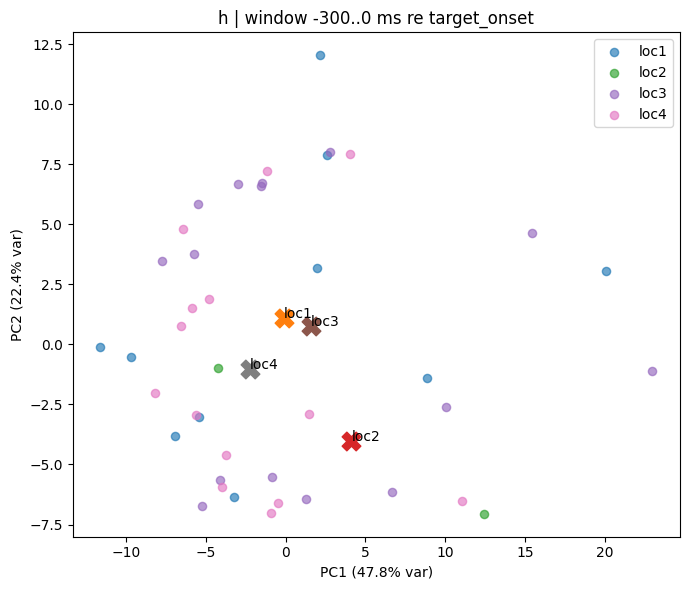

false_alarm pre
[[0.    6.636 1.754 2.98 ]
 [6.636 0.    5.407 7.002]
 [1.754 5.407 0.    4.223]
 [2.98  7.002 4.223 0.   ]]

--- false_alarm post-target ---


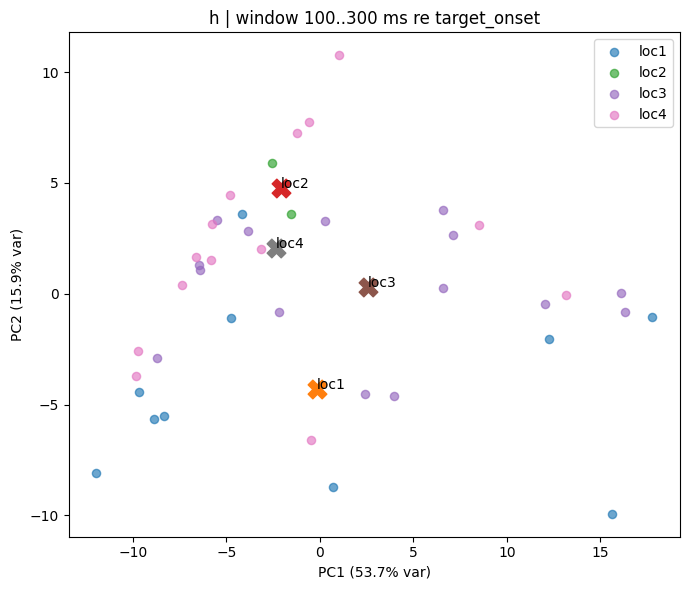

false_alarm post
[[0.    9.251 5.322 6.741]
 [9.251 0.    6.429 2.686]
 [5.322 6.429 0.    5.208]
 [6.741 2.686 5.208 0.   ]]


{'A': {'pre': {'X': array([[1.34654224e+00, 1.15824500e-02, 1.87096272e+01, ...,
           2.27478194e+00, 1.94631648e+00, 3.52267504e+00],
          [1.89108089e-01, 9.39274579e-02, 1.05315981e+01, ...,
           1.08982301e+00, 1.61216033e+00, 1.60532463e+00],
          [1.13828644e-01, 2.56326273e-02, 1.37557325e+01, ...,
           1.09487772e+00, 5.97830892e-01, 2.05093789e+00],
          ...,
          [1.56890541e-01, 7.76840299e-02, 9.23821640e+00, ...,
           9.83333588e-01, 2.24791121e+00, 1.64908636e+00],
          [4.33614790e-01, 2.07098778e-02, 1.70513668e+01, ...,
           1.56486297e+00, 2.51398468e+00, 2.48488736e+00],
          [3.68853271e-01, 2.47069504e-02, 1.51221895e+01, ...,
           1.31496155e+00, 1.49214423e+00, 2.33160090e+00]], dtype=float32),
   'X_plot': array([[ 0.79308033, -0.77369404,  0.66871333, ...,  0.96054757,
            0.23155367,  0.90689343],
          [-0.6848034 ,  1.1129558 , -0.83420086, ..., -0.83912975,
           -0.2265725 ,

In [31]:
# Correct+distractor vs false-alarm: does pre-target geometry predict outcome?
trials_hit = filter_trials(trials_spatial, outcome='correct',     require_distractors=True)
trials_fa  = filter_trials(trials_spatial, outcome='false_alarm', require_distractors=True)
print(f'hit (distractor): {len(trials_hit)},  FA (distractor): {len(trials_fa)}')

compare_spatial_separation(trials_hit, trials_fa, label_A='hit', label_B='false_alarm')

miss: 105


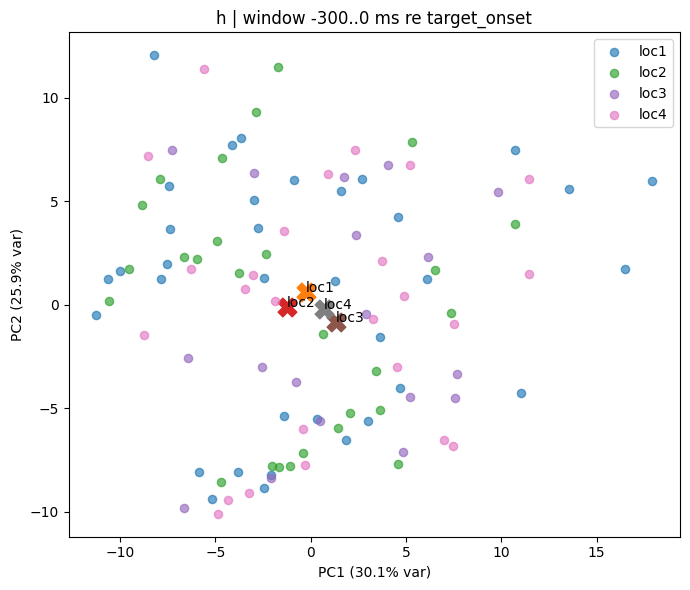

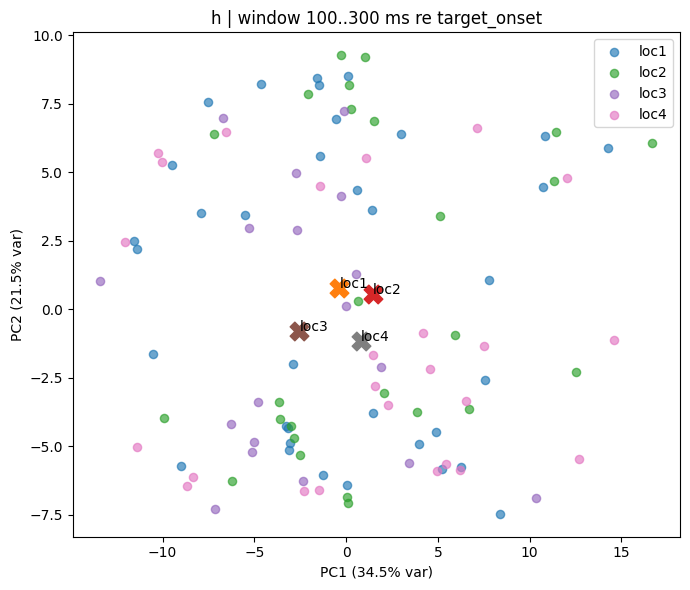

Miss pre-target
[[0.    1.25  2.162 1.265]
 [1.25  0.    2.697 1.964]
 [2.162 2.697 0.    0.899]
 [1.265 1.964 0.899 0.   ]]
Miss post-target
[[0.    1.824 2.683 2.26 ]
 [1.824 0.    4.215 1.852]
 [2.683 4.215 0.    3.357]
 [2.26  1.852 3.357 0.   ]]


array([[0.        , 1.82403433, 2.68308043, 2.25967407],
       [1.82403433, 0.        , 4.21515846, 1.85171974],
       [2.68308043, 4.21515846, 0.        , 3.35683107],
       [2.25967407, 1.85171974, 3.35683107, 0.        ]])

In [32]:
# Miss trials: does spatial representation collapse?
trials_miss = filter_trials(trials_spatial, outcome='miss')
print('miss:', len(trials_miss))

res_miss_pre  = plot_spatial_separation_pca(trials_miss, align_key='target_onset', window_ms=(-300, 0))
res_miss_post = plot_spatial_separation_pca(trials_miss, align_key='target_onset', window_ms=(100, 300))
print_centroid_distances(res_miss_pre,  name='Miss pre-target')
print_centroid_distances(res_miss_post, name='Miss post-target')